### **Naveed Anjum (Reg # 577607)**
##### Sep 30, 2026
---
## **Tutorial 5: CNN for CIFAR-10 Dataset**

## Step 1: Import Libraries

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Step 2: Load and Preprocess the CIFAR-10 Dataset

In [11]:
# Load CIFAR-10 dataset scaled strictly between 0 and 1 using ToTensor (no additional mean/std normalization)
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## Step 3: Visualize Some Data
Let's plot some sample images from the training set along with their corresponding class labels.

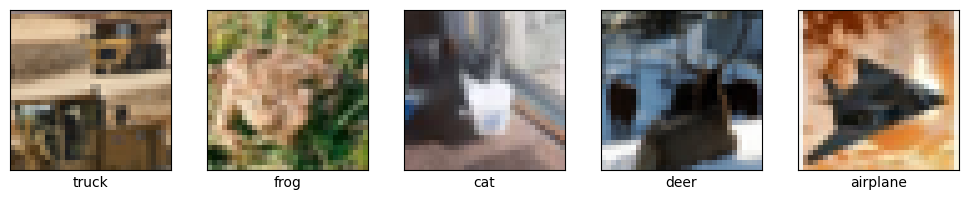

In [12]:
def imshow(img):
    # Images are normalized between 0 and 1, so we display them directly without unnormalization
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show first 5 images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    imshow(images[i])
    plt.xlabel(class_names[labels[i]])
plt.tight_layout()
plt.show()

## Step 4: Build the Convolutional Neural Network (CNN)

In [13]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 16x16
            nn.Dropout(0.25),

            # Block 2 (Increased Complexity)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 8x8
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ImprovedCNN().to(device)

# Install torchinfo for a cleaner model summary if not already installed
!pip install -q torchinfo
from torchinfo import summary

# Print model summary
summary(model, input_size=(64, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ImprovedCNN                              [64, 10]                  --
├─Sequential: 1-1                        [64, 128, 8, 8]           --
│    └─Conv2d: 2-1                       [64, 32, 32, 32]          896
│    └─BatchNorm2d: 2-2                  [64, 32, 32, 32]          64
│    └─ReLU: 2-3                         [64, 32, 32, 32]          --
│    └─Conv2d: 2-4                       [64, 64, 32, 32]          18,496
│    └─BatchNorm2d: 2-5                  [64, 64, 32, 32]          128
│    └─ReLU: 2-6                         [64, 64, 32, 32]          --
│    └─MaxPool2d: 2-7                    [64, 64, 16, 16]          --
│    └─Dropout: 2-8                      [64, 64, 16, 16]          --
│    └─Conv2d: 2-9                       [64, 128, 16, 16]         73,856
│    └─BatchNorm2d: 2-10                 [64, 128, 16, 16]         256
│    └─ReLU: 2-11                        [64, 128, 16, 16]         --
│   

## Step 5: Define Loss Function and Optimizer

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

## Step 6: Train the Model

In [15]:
epochs = 30
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100. * correct / total

    # Evaluation on test set
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(testloader)
    val_acc = 100. * correct_val / total_val

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{epochs}] | ' \
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | ' \
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

    # --- Early Stopping Criteria ---
    if epoch > 0:
        prev_train_loss = history['train_loss'][epoch - 1]
        prev_val_loss = history['val_loss'][epoch - 1]

        # 1) Validation loss starts increasing (Disabled by user request)
        # if val_loss > prev_val_loss:
        #     print(f"Early stopping triggered: Validation loss increased from {prev_val_loss:.4f} to {val_loss:.4f}.")
        #     break

        # 2) Training loss is less than validation loss
        if train_loss < val_loss:
            print(f"Early stopping triggered: Training loss ({train_loss:.4f}) is less than validation loss ({val_loss:.4f}).")
            break

        # 3) Training loss stops decreasing
        if train_loss >= prev_train_loss:
            print(f"Early stopping triggered: Training loss stopped decreasing (from {prev_train_loss:.4f} to {train_loss:.4f}).")
            break

Epoch [1/30] | Train Loss: 1.6639 | Train Acc: 40.27% | Val Loss: 1.3927 | Val Acc: 51.39%
Epoch [2/30] | Train Loss: 1.2313 | Train Acc: 55.91% | Val Loss: 1.0883 | Val Acc: 60.69%
Epoch [3/30] | Train Loss: 1.0804 | Train Acc: 61.85% | Val Loss: 0.9247 | Val Acc: 67.41%
Epoch [4/30] | Train Loss: 0.9809 | Train Acc: 65.81% | Val Loss: 0.8831 | Val Acc: 69.20%
Epoch [5/30] | Train Loss: 0.9139 | Train Acc: 68.24% | Val Loss: 0.7446 | Val Acc: 74.95%
Epoch [6/30] | Train Loss: 0.7919 | Train Acc: 72.54% | Val Loss: 0.6542 | Val Acc: 77.58%
Epoch [7/30] | Train Loss: 0.7451 | Train Acc: 74.14% | Val Loss: 0.6733 | Val Acc: 77.09%
Epoch [8/30] | Train Loss: 0.7097 | Train Acc: 75.49% | Val Loss: 0.6532 | Val Acc: 77.14%
Epoch [9/30] | Train Loss: 0.6659 | Train Acc: 76.86% | Val Loss: 0.6100 | Val Acc: 78.93%
Epoch [10/30] | Train Loss: 0.6399 | Train Acc: 77.89% | Val Loss: 0.5870 | Val Acc: 79.91%
Epoch [11/30] | Train Loss: 0.5627 | Train Acc: 80.49% | Val Loss: 0.5605 | Val Acc: 80.9

## Step 7: Model Evaluation

In [16]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy of the model on the 10000 test images: {100 * correct / total:.2f}%')

Test Accuracy of the model on the 10000 test images: 81.69%


## Step 8: Plot Training and Validation Accuracy/Loss

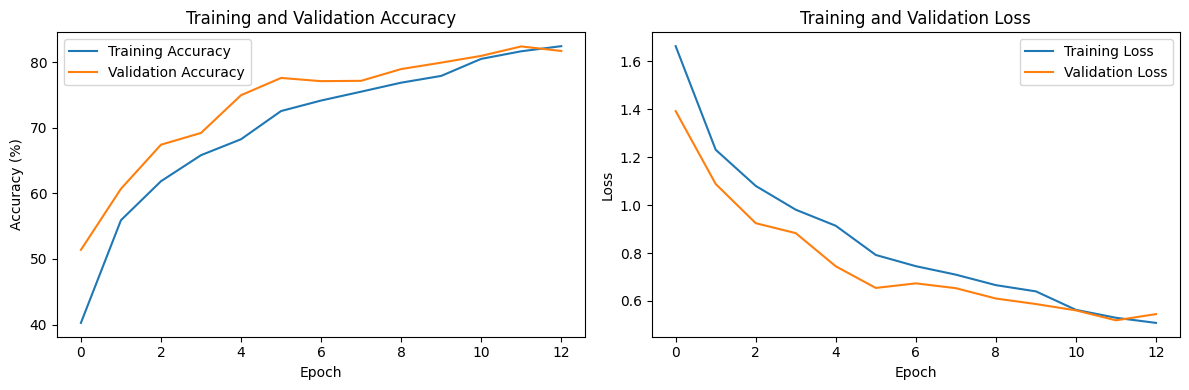

In [17]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Step 9 & 10: Predictions and Results Visualization

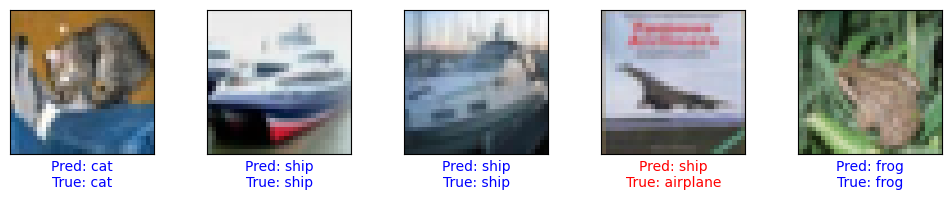

In [18]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images[:5])
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Images are in [0, 1] range, display directly without unnormalization
    img = images[i].cpu()
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    pred_label = class_names[predicted[i].item()]
    true_label = class_names[labels[i].item()]
    color = 'blue' if pred_label == true_label else 'red'
    plt.xlabel(f'Pred: {pred_label}\nTrue: {true_label}', color=color)

plt.tight_layout()
plt.show()